In [1]:
import os
import sys
import copy
import joblib

sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import torch

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import property_driven_ml.logics as logics
import property_driven_ml.training as training

from withProperties.attack_ import (
    DoSHttpFloodPostcondition,
    TabularRuleConstraint,
    PortscanPostcondition,
    GlobalBounds
)
from sklearn.model_selection import train_test_split
from utils.utils import *
from sklearn.preprocessing import StandardScaler
from utils.models import build_model
from specs import ATTACK_SPECS
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
TARGET_LABELS = ["BENIGN", "DOS_HTTP_FLOOD", "PORTSCAN"]
PROPERTY_MODEL_FEATURES = MODEL_NUMERIC_FEATURES + ENGINEERED_FEATURES
FEATURE_COLS = PROPERTY_MODEL_FEATURES

label_to_idx = {label: i for i, label in enumerate(TARGET_LABELS)}
idx = {name: i for i, name in enumerate(FEATURE_COLS)}

BOOLEAN_FEATURES = ["valid_tcp_handshake", "valid_http_conn"]
FROZEN_FEATURES = [
    "valid_tcp_handshake",
    "valid_http_conn",
    "uniq_dst_ports",
    "pkts_per_port",
    "scan_duration",
    "fail_ratio",
]

FROZEN_IDXS = [idx[f] for f in FROZEN_FEATURES if f in idx]

BATCH_SIZE = 1024
RANDOM_STATE = 42
NUM_EPOCHS = 5
LEARNING_RATE = 1e-3

LAMBDA_DOS = 2.0
LAMBDA_SCAN = 0.1
PGD_STEPS = 10
PGD_RESTARTS = 1
PGD_STEP_SIZE = 0.01

In [33]:
raw_train_df = pd.read_csv("../data/ciciot2023_preprocessed.tsv", on_bad_lines="skip", delimiter="\t")
# df_cicids2017 = pd.read_csv("../data/cicids2017_preprocessed.tsv", on_bad_lines="skip", delimiter="\t")
# df_ciciot2023 = pd.read_csv("../data/ciciot2023_preprocessed.tsv", on_bad_lines="skip", delimiter="\t")
dataset_name = "CICIoT2023"
print(raw_train_df)

print_section("Loading data")
print_df_summary(raw_train_df, "Raw " + dataset_name + " train")

train_full_df = filter_labels(raw_train_df, TARGET_LABELS, label_to_idx)

print("Training set label distribution before split:")
print_label_distribution(train_full_df)

train_df, test_df = train_test_split(
    train_full_df,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=train_full_df["label"],
)
train_df, val_df = train_test_split(
    train_full_df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=train_full_df["label"],
)

                   ts                 uid                  id.orig_h  \
0        1.660668e+09  Ch3ncG1kMRNM7V7Bz8             192.168.137.17   
1        1.660671e+09  CGoYkg1Yv95df4aHR5            192.168.137.178   
2        1.660680e+09  CBMKGc4I6qc5R9ZlAj            192.168.137.109   
3        1.664870e+09  CL1qy43yrQxloFa1Ze             192.168.137.41   
4        1.660680e+09  CS3uF51AyiZ2Qng7xk             192.168.137.15   
...               ...                 ...                        ...   
2922692  1.665263e+09  Ct7pfv3x32wzezGTY9  fe80::ea1b:69ff:fef8:d6e6   
2922693  1.665263e+09  CTx2a14SfJoHvctCWb  fe80::ea1b:69ff:fef8:d6e6   
2922694  1.665264e+09  CvsxK23jNjRXUhJHM3  fe80::ea1b:69ff:fef8:d6e6   
2922695  1.665264e+09   CvSVOTt5PvkZvZN5h  fe80::ea1b:69ff:fef8:d6e6   
2922696  1.661974e+09  CIVnGJ3u0JyzJWSdU6  fe80::ea1b:69ff:fef8:d6e6   

         id.orig_p        id.resp_h  id.resp_p proto service    duration  \
0            22777  192.168.137.123       4070   tcp       

In [35]:
train_df.head()

,ts,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,proto,service,duration,orig_bytes,...,valid_http_conn,orig_pkt_rate,orig_byte_rate,window_id,is_failed_conn,uniq_dst_ports,pkts_per_port,scan_duration,fail_ratio,label_id
2222661,1.664287e+09,CXatEw1t2l6S8v13Rh,192.168.137.178,54798,192.168.137.40,19780,tcp,-,0.059432,0.0,...,0,16.825952,0.000000,332857329,1,1000,1.031000,0.174103,1.0,2
1944111,1.665163e+09,CRR31j1fHCIDrNH9e8,192.168.137.128,3,192.168.137.154,3,icmp,-,4.019495,3253.0,...,0,2.487875,809.305647,333032590,0,1,10.000000,4.019495,0.0,0
2137257,1.664212e+09,CukQ211vTW4NaV7Egf,192.168.137.178,56551,192.168.137.163,5631,tcp,-,0.337021,0.0,...,0,2.967174,0.000000,332842496,1,1000,1.004000,0.391653,1.0,2
2172792,1.664213e+09,Cle2av4Vbb14dFZTf1,192.168.137.178,41287,192.168.137.196,6002,tcp,-,0.101929,0.0,...,0,9.810751,0.000000,332842603,1,934,1.127409,0.272771,1.0,2
2816655,1.665213e+09,CUHOeW3nRWvFG4ZVP8,192.168.137.76,44443,192.168.137.1,53,udp,dns,0.001701,44.0,...,0,587.889477,25867.136978,333042509,0,1,1.000000,0.001701,0.0,0


# Scaling and Dataloaders

In [36]:
def make_loader(df: pd.DataFrame, feature_cols: list[str], batch_size: int = 1024, shuffle: bool = False) -> DataLoader:
    x = torch.tensor(df[feature_cols].to_numpy(), dtype=torch.float32)
    y = torch.tensor(df["label_id"].to_numpy(), dtype=torch.long)
    return DataLoader(TensorDataset(x, y), batch_size=batch_size, shuffle=shuffle)


def scale_value(col: str, raw_value: float, scaler: StandardScaler, scale_cols: list[str]) -> float:
    i = scale_cols.index(col)
    return (raw_value - scaler.mean_[i]) / scaler.scale_[i]


def make_scaled_attack_specs(raw_specs: dict, scaler: StandardScaler, scale_cols: list[str]) -> dict:
    specs = copy.deepcopy(raw_specs)
    scale_map = {
        "validity": {
            "valid_packet_size_min_pkts": "orig_pkts",
            "valid_packet_size_min_total_bytes": "orig_bytes",
        },
        "dos_http_flood": {
            "mal_time_elapsed_min": "time_elapsed",
            "mal_time_elapsed_max": "time_elapsed",
            "valid_pkt_size_total_min": "orig_bytes",
            "mal_byte_rate_min": "orig_byte_rate",
            "mal_pkt_rate_min": "orig_pkt_rate",
        },
        "portscan": {
            "min_uniq_dst_ports": "uniq_dst_ports",
            "max_pkts_per_port": "pkts_per_port",
            "max_scan_duration": "scan_duration",
            "min_fail_ratio": "fail_ratio",
        },
    }

    for attack_name, key_to_col in scale_map.items():
        for spec_key, col in key_to_col.items():
            specs[attack_name][spec_key] = scale_value(col, raw_specs[attack_name][spec_key], scaler, scale_cols)

    return specs

In [37]:
scale_cols = [col for col in FEATURE_COLS if col not in BOOLEAN_FEATURES]
scaler = StandardScaler()

train_df[scale_cols] = scaler.fit_transform(train_df[scale_cols])
test_df[scale_cols] = scaler.transform(test_df[scale_cols])
val_df[scale_cols] = scaler.transform(val_df[scale_cols])

scaled_attack_specs = make_scaled_attack_specs(ATTACK_SPECS, scaler, scale_cols)

train_loader = make_loader(train_df, FEATURE_COLS, batch_size=BATCH_SIZE, shuffle=True)
test_loader = make_loader(test_df, FEATURE_COLS, batch_size=BATCH_SIZE)
val_loader = make_loader(val_df, FEATURE_COLS, batch_size=BATCH_SIZE)

In [38]:
train_df.head()

,ts,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,proto,service,duration,orig_bytes,...,valid_http_conn,orig_pkt_rate,orig_byte_rate,window_id,is_failed_conn,uniq_dst_ports,pkts_per_port,scan_duration,fail_ratio,label_id
2222661,1.664287e+09,CXatEw1t2l6S8v13Rh,192.168.137.178,54798,192.168.137.40,19780,tcp,-,-0.047394,-0.006334,...,0,-0.442105,-0.004812,332857329,1,2.513685,-0.397201,-0.078041,1.061494,2
1944111,1.665163e+09,CRR31j1fHCIDrNH9e8,192.168.137.128,3,192.168.137.154,3,icmp,-,-0.039890,-0.004810,...,0,-0.442144,-0.004749,333032590,0,-0.461506,-0.391179,-0.073150,-1.143491,0
2137257,1.664212e+09,CukQ211vTW4NaV7Egf,192.168.137.178,56551,192.168.137.163,5631,tcp,-,-0.046868,-0.006334,...,0,-0.442143,-0.004812,332842496,1,2.513685,-0.397219,-0.077765,1.061494,2
2172792,1.664213e+09,Cle2av4Vbb14dFZTf1,192.168.137.178,41287,192.168.137.196,6002,tcp,-,-0.047313,-0.006334,...,0,-0.442124,-0.004812,332842603,1,2.317126,-0.397136,-0.077916,1.061494,2
2816655,1.665213e+09,CUHOeW3nRWvFG4ZVP8,192.168.137.76,44443,192.168.137.1,53,udp,dns,-0.047503,-0.006314,...,0,-0.440563,-0.002778,333042509,0,-0.461506,-0.397222,-0.078261,-1.143491,0


# Setup model and constraints

In [39]:
logic = logics.GoedelFuzzyLogic()
# bool_logic = logics.BooleanLogic()

lower_bound = torch.tensor(
    train_df[FEATURE_COLS].min().to_numpy(),
    dtype=torch.float32,
    device=device,
)

upper_bound = torch.tensor(
    train_df[FEATURE_COLS].max().to_numpy(),
    dtype=torch.float32,
    device=device,
)

model = build_model(
    model_type="mlp",
    n_features=len(FEATURE_COLS),
    num_classes=len(label_to_idx),
).to(device)

In [40]:
precondition=GlobalBounds(
    device=device,
    lower_bound=lower_bound,
    upper_bound=upper_bound
)

dos_constraint = TabularRuleConstraint(
    device,
    precondition=precondition,
    postcondition=DoSHttpFloodPostcondition(
        idx=idx,
        class_idx=label_to_idx["DOS_HTTP_FLOOD"],
        dos_http_flood_specs=scaled_attack_specs["dos_http_flood"],
        validity_specs=scaled_attack_specs["validity"],
        min_prob=0.50
    )
)

scan_constraint = TabularRuleConstraint(
    device,
    precondition=precondition,
    postcondition=PortscanPostcondition(
        idx=idx,
        class_idx=label_to_idx["PORTSCAN"],
        min_prob=0.75,
        portscan_specs=scaled_attack_specs["portscan"]
    )
)

## Train Helpers

In [41]:
def clamp_to_bounds(x_adv: torch.Tensor, lower_bound: torch.Tensor, upper_bound: torch.Tensor) -> torch.Tensor:
    return torch.max(torch.min(x_adv, upper_bound), lower_bound)


def project_x_adv(
    x_adv: torch.Tensor,
    x: torch.Tensor,
    lower_bound: torch.Tensor,
    upper_bound: torch.Tensor,
    frozen_idxs: list[int],
) -> torch.Tensor:
    x_adv = clamp_to_bounds(x_adv, lower_bound, upper_bound).clone()
    x_adv[:, frozen_idxs] = x[:, frozen_idxs]
    return x_adv


def update_rule_stats_for_label(stats: dict, parts: dict, y: torch.Tensor, class_idx: int) -> None:
    label_mask = y == class_idx

    for name, mask in parts.items():
        filtered_mask = mask.detach().bool()[label_mask]
        stats.setdefault(name, {"true": 0, "total": 0})
        stats[name]["true"] += filtered_mask.sum().item()
        stats[name]["total"] += filtered_mask.numel()


def print_rule_stats(name: str, stats: dict) -> None:
    print(f"\n{name} rule debug - true-label rows only")

    for part_name, values in stats.items():
        true = values["true"]
        total = values["total"]
        print(f"{part_name:25s} {true:8d}/{total:<8d}  {true / max(total, 1):.4f}")


def make_weighted_ce_loss(train_df: pd.DataFrame, device: torch.device) -> nn.CrossEntropyLoss:
    class_counts = train_df["label_id"].value_counts().sort_index().to_numpy()
    class_weights = 1.0 / torch.tensor(class_counts, dtype=torch.float32)
    class_weights = (class_weights / class_weights.mean()).to(device)

    print("class_counts:", class_counts)
    print("class_weights:", class_weights)
    return nn.CrossEntropyLoss(weight=class_weights)

# Training

In [42]:
def train_one_epoch(
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    oracle: training.PGD,
    logic,
    ce_fn
) -> dict:
    model.train()
    totals = {"ce_loss": 0.0, "dos_loss": 0.0, "scan_loss": 0.0, "dos_sat": 0.0, "scan_sat": 0.0}
    dos_debug_stats, scan_debug_stats = {}, {}

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        ce_loss = ce_fn(logits, y)

        x_adv_dos = oracle.attack(model, x, None, dos_constraint)
        x_adv_dos = project_x_adv(x_adv_dos, x, lower_bound, upper_bound, FROZEN_IDXS)
        dos_loss, dos_sat = dos_constraint.eval(model, x, x_adv_dos, None, logic, reduction="mean")

        x_adv_scan = oracle.attack(model, x, None, scan_constraint)
        x_adv_scan = project_x_adv(x_adv_scan, x, lower_bound, upper_bound, FROZEN_IDXS)
        scan_loss, scan_sat = scan_constraint.eval(model, x, x_adv_scan, None, logic, reduction="mean")

        loss = ce_loss + LAMBDA_DOS * dos_loss + LAMBDA_SCAN * scan_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        totals["ce_loss"] += ce_loss.item()
        totals["dos_loss"] += dos_loss.item()
        totals["scan_loss"] += scan_loss.item()
        totals["dos_sat"] += dos_sat.item()
        totals["scan_sat"] += scan_sat.item()

        with torch.no_grad():
            update_rule_stats_for_label(
                dos_debug_stats,
                dos_constraint.postcondition.debug_parts(model, x, x_adv_dos),
                y,
                label_to_idx["DOS_HTTP_FLOOD"],
            )
            update_rule_stats_for_label(
                scan_debug_stats,
                scan_constraint.postcondition.debug_parts(model, x, x_adv_scan),
                y,
                label_to_idx["PORTSCAN"],
            )

    batches = len(train_loader)
    metrics = {key: value / batches for key, value in totals.items()}
    metrics["dos_debug_stats"] = dos_debug_stats
    metrics["scan_debug_stats"] = scan_debug_stats
    return metrics


@torch.no_grad()
def evaluate_epoch_split(
    model: nn.Module,
    loader: DataLoader,
) -> dict:
    model.eval()
    correct = 0.0
    dos_sat_total = 0.0
    scan_sat_total = 0.0
    n = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        preds = logits.argmax(dim=1)

        dos_loss, dos_sat = dos_constraint.eval(model, x, x, None, logic, reduction="sum")
        scan_loss, scan_sat = scan_constraint.eval(model, x, x, None, logic, reduction="sum")

        correct += (preds == y).float().sum().item()
        dos_sat_total += dos_sat.item()
        scan_sat_total += scan_sat.item()
        n += x.size(0)

    return {
        "acc": correct / n,
        "dos_loss": dos_loss / n,
        "dos_sat": dos_sat_total / n,
        "scan_loss": scan_loss / n,
        "scan_sat": scan_sat_total / n,
    }

In [43]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
oracle = training.PGD(logic, device, steps=PGD_STEPS, restarts=PGD_RESTARTS, step_size=PGD_STEP_SIZE)
ce_fn = make_weighted_ce_loss(train_df, device=device)

PGD steps=10 restarts=1 step_size=tensor([0.0100], device='cuda:0')
class_counts: [273804 116361 173226]
class_weights: tensor([0.6081, 1.4308, 0.9611], device='cuda:0')


In [44]:
best_score = -float("inf")
best_state = None

for epoch in range(1, NUM_EPOCHS + 1):
    train_metrics = train_one_epoch(
        model=model,
        optimizer=optimizer,
        oracle=oracle,
        logic=logic,
        ce_fn=ce_fn,
    )

    val_metrics = evaluate_epoch_split(model, val_loader)
    if score > best_score:
        best_score = score
        best_state = copy.deepcopy(model.state_dict())

    print(
        f"epoch={epoch} \n"
        f"----- TRAIN -----\n"
        f"ce_loss={train_metrics['ce_loss']:.4f} "
        f"dos_loss={train_metrics['dos_loss']:.4f} "
        f"scan_loss={train_metrics['scan_loss']:.4f} "
        f"dos_sat={train_metrics['dos_sat']:.4f} "
        f"scan_sat={train_metrics['scan_sat']:.4f} \n "
        f"----- VALIDATION -----\n"
        f"val_acc={val_metrics['acc']:.4f} "
        f"val_dos_loss={val_metrics['dos_loss']:.4f} "
        f"val_dos_sat={val_metrics['dos_sat']:.4f} "
        f"val_scan_loss={val_metrics['scan_loss']:.4f} "
        f"val_scan_sat={val_metrics['scan_sat']:.4f}"
    )

    print_rule_stats("DoS HTTP Flood", train_metrics["dos_debug_stats"])
    print_rule_stats("Portscan", train_metrics["scan_debug_stats"])

epoch=1 
----- TRAIN -----
ce_loss=0.3476 dos_loss=0.0023 scan_loss=0.1304 dos_sat=0.9854 scan_sat=0.9829 
 ----- VALIDATION -----
val_acc=0.8952 val_dos_loss=0.0002 val_dos_sat=0.9528 val_scan_loss=0.0022 val_scan_sat=0.9939

DoS HTTP Flood rule debug - true-label rows only
valid_tcp_handshake          97752/116361    0.8401
valid_http_conn             108621/116361    0.9335
mal_time_elapsed_min        116361/116361    1.0000
mal_time_elapsed_max        115314/116361    0.9910
valid_pkt_size_total_min     99356/116361    0.8539
high_byte_rate               91101/116361    0.7829
high_pkt_rate                26037/116361    0.2238
prediction_ok                89518/116361    0.7693
malicious_signal             93210/116361    0.8010
antecedent_true              69724/116361    0.5992

Portscan rule debug - true-label rows only
many_dst_ports              114903/173226    0.6633
high_fail_ratio             121907/173226    0.7037
low_pkts_per_port           128182/173226    0.7400
shor

In [45]:
model.load_state_dict(best_state)

test_metrics = evaluate_epoch_split(model, test_loader)

print(
    f"----- TEST -----\n"
    f"test_acc={test_metrics['acc']:.4f} "
    f"test_dos_loss={test_metrics['dos_loss']:.4f} "
    f"test_dos_sat={test_metrics['dos_sat']:.4f} "
    f"test_scan_loss={test_metrics['scan_loss']:.4f} "
    f"test_scan_sat={test_metrics['scan_sat']:.4f}"
)

----- TEST -----
test_acc=0.9140 test_dos_loss=0.0003 test_dos_sat=0.9524 test_scan_loss=0.0009 test_scan_sat=0.9996


In [46]:
def save_property_model(
    model,
    save_path,
    features,
    model_type,
    scaler
):
    joblib.dump(
        {
            "model": model.cpu(),
            "features": features,
            "model_type": model_type,
            "scaler": scaler
        },
        save_path,
    )

    print(f"Saved model to: {save_path}")

In [47]:
save_property_model(
    model,
    "models/property_model_cicids2017_3_classes.joblib",
    features=FEATURE_COLS,
    model_type="mlp",
    scaler=scaler
)

Saved model to: models/property_model_cicids2017_3_classes.joblib


In [48]:
import joblib
bundle = joblib.load("models/property_model_cicids2017_3_classes.joblib")
print(bundle.keys())

dict_keys(['model', 'features', 'model_type', 'scaler'])


# Evaluate cross-data

In [61]:
def prepare_eval_df(
    df: pd.DataFrame,
    target_labels: list[str],
    label_to_idx: dict[str, int],
    scaler: StandardScaler
) -> pd.DataFrame:
    df = filter_labels(df, target_labels, label_to_idx)
    df[scale_cols] = scaler.transform(df[scale_cols])
    return df

df_cicids2017_train = pd.read_csv("../data/cicids2017_preprocessed.tsv", on_bad_lines="skip", delimiter="\t")
cross_eval_df = prepare_eval_df(df_cicids2017_train, TARGET_LABELS, label_to_idx, scaler)
cross_eval_dataset_name = "CICIDS2017"

In [62]:
@torch.no_grad()
def evaluate_model_metrics(
    model: nn.Module,
    df: pd.DataFrame,
    batch_size: int = 1024,
) -> tuple[dict, pd.DataFrame, np.ndarray, list[str]]:
    loader = make_loader(df, FEATURE_COLS, batch_size=batch_size)
    idx_to_label = {v: k for k, v in label_to_idx.items()}
    label_ids = list(range(len(idx_to_label)))
    labels = [idx_to_label[i] for i in label_ids]

    model = model.to(device)
    model.eval()

    y_true, y_pred = [], []
    totals = {"dos_loss": 0.0, "scan_loss": 0.0, "dos_sat": 0.0, "scan_sat": 0.0}
    dos_debug_stats, scan_debug_stats = {}, {}
    n = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        preds = logits.argmax(dim=1)

        dos_loss, dos_sat = dos_constraint.eval(model, x, x, None, logic, reduction="sum")
        scan_loss, scan_sat = scan_constraint.eval(model, x, x, None, logic, reduction="sum")

        update_rule_stats_for_label(
            dos_debug_stats,
            dos_constraint.postcondition.debug_parts(model, x, x),
            y,
            label_to_idx["DOS_HTTP_FLOOD"],
        )
        update_rule_stats_for_label(
            scan_debug_stats,
            scan_constraint.postcondition.debug_parts(model, x, x),
            y,
            label_to_idx["PORTSCAN"],
        )

        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

        totals["dos_loss"] += dos_loss.item()
        totals["scan_loss"] += scan_loss.item()
        totals["dos_sat"] += dos_sat.item()
        totals["scan_sat"] += scan_sat.item()
        n += x.size(0)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    report = classification_report(
        y_true,
        y_pred,
        labels=label_ids,
        target_names=labels,
        digits=4,
        zero_division=0,
        output_dict=True,
    )

    for label_id, label_name in zip(label_ids, labels):
        mask = y_true == label_id
        report[label_name]["accuracy"] = float((y_pred[mask] == label_id).mean()) if mask.sum() else 0.0

    metrics = {
        "acc": float((y_true == y_pred).mean()),
        "dos_loss": totals["dos_loss"] / max(n, 1),
        "scan_loss": totals["scan_loss"] / max(n, 1),
        "dos_sat": totals["dos_sat"] / max(n, 1),
        "scan_sat": totals["scan_sat"] / max(n, 1),
    }

    print_rule_stats("Cross-dataset DoS HTTP Flood", dos_debug_stats)
    print_rule_stats("Cross-dataset Portscan", scan_debug_stats)

    cm = confusion_matrix(y_true, y_pred, labels=label_ids)
    return metrics, pd.DataFrame(report).T, cm, labels

In [63]:
metrics, report_df, cm, labels = evaluate_model_metrics(
    model,
    cross_eval_df
)


Cross-dataset DoS HTTP Flood rule debug - true-label rows only
valid_tcp_handshake         154659/155349    0.9956
valid_http_conn             155349/155349    1.0000
mal_time_elapsed_min        155349/155349    1.0000
mal_time_elapsed_max        155348/155349    1.0000
valid_pkt_size_total_min    155349/155349    1.0000
high_byte_rate              153026/155349    0.9850
high_pkt_rate               152954/155349    0.9846
prediction_ok               154628/155349    0.9954
malicious_signal            153661/155349    0.9891
antecedent_true             152971/155349    0.9847

Cross-dataset Portscan rule debug - true-label rows only
many_dst_ports              153030/154034    0.9935
high_fail_ratio             153195/154034    0.9946
low_pkts_per_port           153719/154034    0.9980
short_scan_duration         139771/154034    0.9074
prediction_ok               153412/154034    0.9960
scan_signal                 153948/154034    0.9994
antecedent_true             152986/154034    0

In [64]:
def plot_eval_summary(metrics, report_df, cm, labels, model_name):
    fig, (ax1, ax2, ax3) = plt.subplots(
        3,
        1,
        figsize=(11, 15),
        gridspec_kw={"height_ratios": [3, 1.2, 2.8]},
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        ax=ax1,
    )
    ax1.set_xlabel("Predicted")
    ax1.set_ylabel("Actual")
    ax1.set_title(f"{model_name} Confusion Matrix")

    ax2.axis("off")
    metrics_text = "\n".join(
        [
            f"accuracy: {metrics['acc']:.3f}",
            f"dos_loss: {metrics['dos_loss']:.3f}",
            f"scan_loss: {metrics['scan_loss']:.3f}",
            f"dos_sat: {metrics['dos_sat']:.3f}",
            f"scan_sat: {metrics['scan_sat']:.3f}",
        ]
    )
    ax2.text(
        0.01,
        0.95,
        metrics_text,
        va="top",
        ha="left",
        family="monospace",
        fontsize=11,
    )

    ax3.axis("off")
    ax3.text(
        0.01,
        0.95,
        report_df.round(3).to_string(),
        va="top",
        ha="left",
        family="monospace",
        fontsize=9,
    )
    ax3.set_title("Classification Report + Per-Label Accuracy")

    plt.tight_layout()
    plt.show()

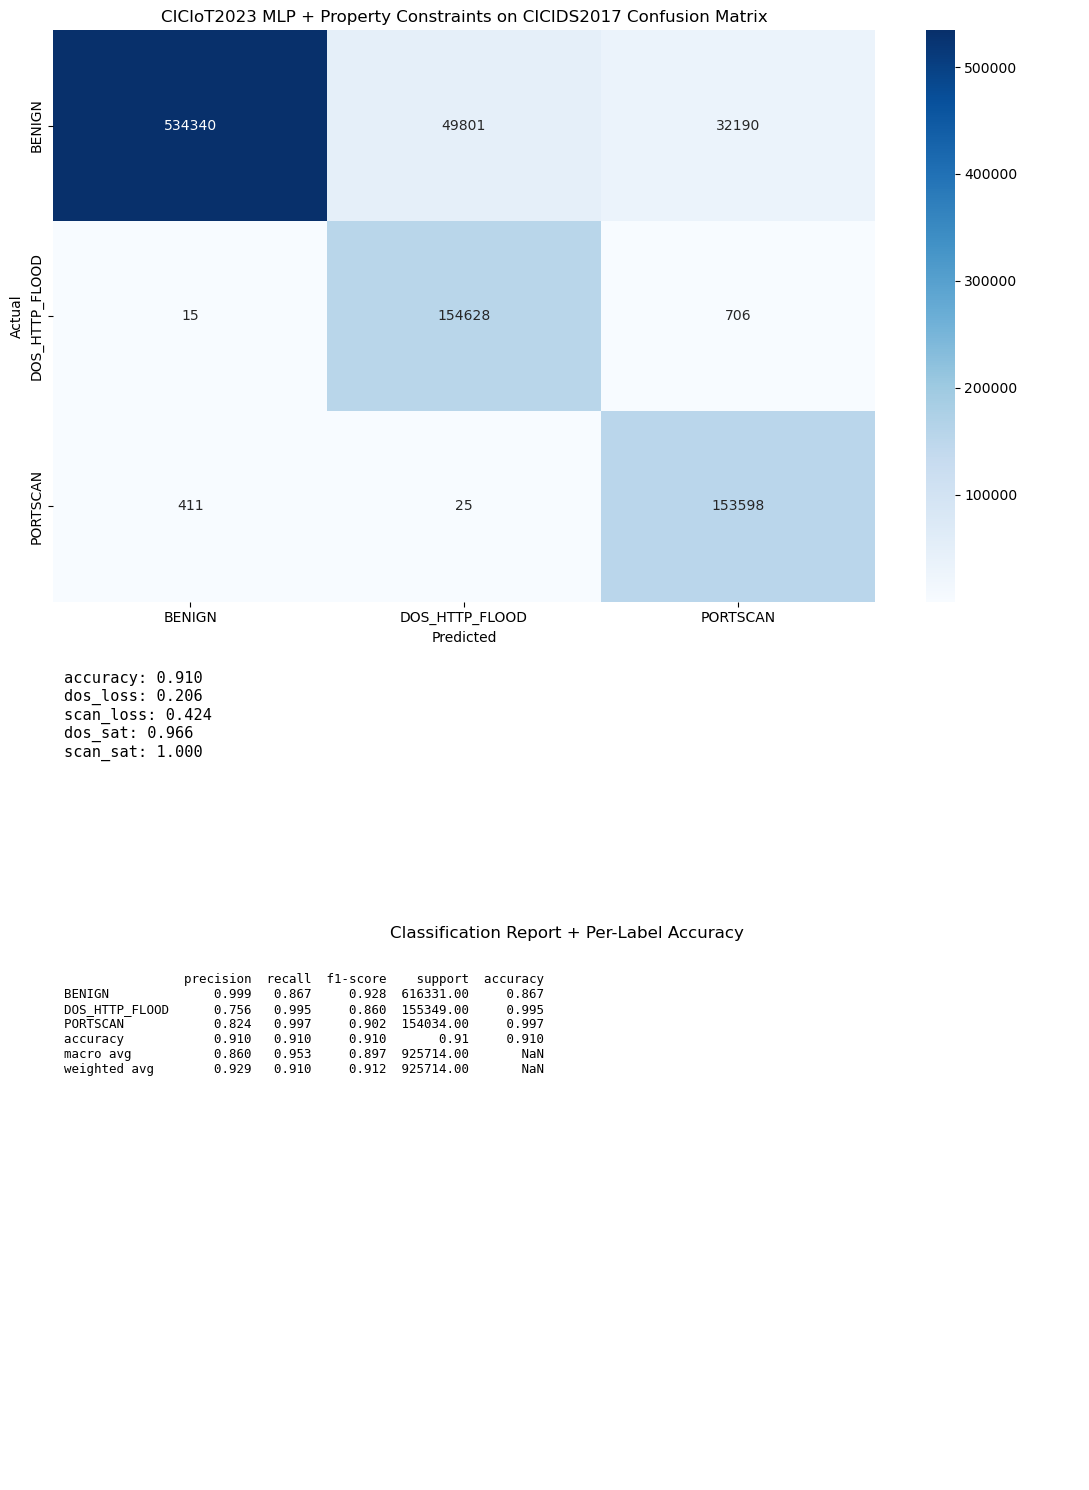

In [65]:
plot_eval_summary(
    metrics,
    report_df,
    cm,
    labels,
    model_name=f"{dataset_name} MLP + Property Constraints on {cross_eval_dataset_name}",
)